# Global sensitivity analysis: Mass-action kinetics, double binding 

Nathaniel Linden (UCSD MAE) - March  2023

In [73]:
import numpy as np
from SALib.sample import sobol as sobol_samp
from SALib.sample import morris as morris_samp
from SALib.analyze import sobol as sobol_analyze
from SALib.analyze import morris as morris_analyze
from SALib.analyze.hdmr import analyze as hdmr_analyze
import os
import sys

import jax
import jax.numpy as jnp
from jax import lax
import equinox as eqx
import diffrax as dfrx

import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from scipy.stats import t

jax.config.update('jax_enable_x64', True)
# load code
sys.path.insert(0, '/scratch/nlinden/AMPK/src/ampk_models/odes')
sys.path.insert(0, '/scratch/nlinden/AMPK/src/ampk_models/global_sensitivity_analysis')
sys.path.insert(0, '../odes')
import ampk_MM_single_mech_diffrax as model
import ampk_MM_single_mech as model1
from gsa_utils import *

%matplotlib inline
plt.style.use('~/.matplotlib/custom.mplstyle')
mpl.rcParams['figure.autolayout'] = True

### Now load the parameter values and solutions for the sensitivity analysis
We will use the same parameter values as in the previous notebook, but we will use the solutions generated with the diffrax solver.
Additionally, we will use the $\pm 50 \%$ bounds for the sensitivity analysis.

In [74]:
param_vals_sobol_corr = np.load('./MM_single_mech/param_vals_sobol_MM_corr.npy')

sobol_sols_corr = np.load('./MM_single_mech/sols_sobol_corr.npy')

# reshape into 2D array
sobol_sols_corr = sobol_sols_corr.reshape(sobol_sols_corr.shape[0]*sobol_sols_corr.shape[1], sobol_sols_corr.shape[2])
nsols, nqoi = sobol_sols_corr.shape

In [75]:
ss_pre = [(sol[1], idx) for sol, idx in zip(sobol_sols_corr, range(nsols))]
print('There are', nsols, 'total correlated Sobol samples.')
print(sum([ss[0] < 0.0 for ss in ss_pre]), 'of them have negative initial steady-states')

neg_idxs = []
for ss in ss_pre:
    if ss[0] <0.0:
        neg_idxs.append(ss[1])
# param_vals_sobol_corr[neg_idxs]


There are 30720 total correlated Sobol samples.
0 of them have negative initial steady-states


In [76]:
nominal_vals_MM = [
   2.5e-3, # KdAMP
   1.5e-3, # KdADP
   1.7e-3, # KdATP
   0.357, # kPhosCaMKK
   1.5e-2,  # KmCaMKK
   3.92e-2, # kPhosLKB1
   1.4,  # KmLKB1
   1.1e-1, # kDephosPP
   6.7e-2, # KmPP
   6.33, # kPhosAMPK
   4.67e-3, # KmAMPK
   1.1e-1, # kDephosPP1
   6.7e-2, # KmPP1
   1e-3, # AMPKAR
]

lb_mult = 0.5
ub_mult = 1.5
bounds_MM = [[lb_mult*param, ub_mult*param] for param in nominal_vals_MM]
param_names_MM = ['KdAMP', 'KdADP', 'KdATP', 'kPhosCaMKK', 'KmCamKK', 'kPhosLKB1', 'KmLKB1', 'kDephosPP', 'KmPP', 'kPhosAMPK', 'KmAMPK', 
               'kDephosPP1', 'KmPP1', 'AMPKAR']

# dictionary of the problem for SALib
problem = {'num_vars':14, 'names':param_names_MM, 'bounds': bounds_MM,}

# random seed for reproducibility
seed = np.random.seed(seed=2048)

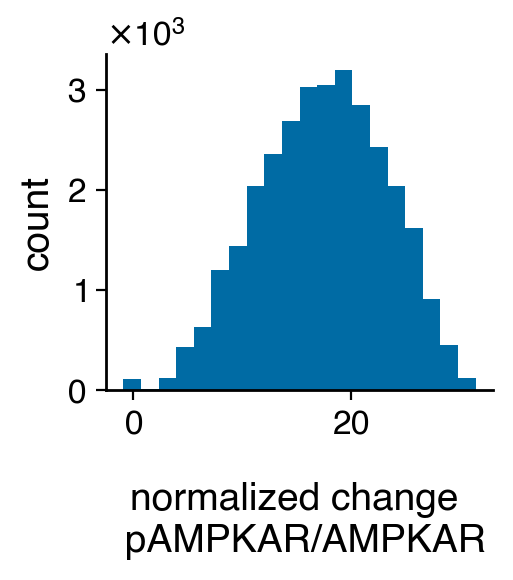

In [77]:
# histogram of output quantities of interest
fig, ax = plt.subplots(1,1, figsize=(8/3,3))
ax.hist(sobol_sols_corr[:,0], bins=20)
ax.set_xlabel('normalized change \n pAMPKAR/AMPKAR', labelpad=15)
ax.set_ylabel('count')
# ax[1].hist(sobol_sols_corr[:,1], bins=20)
# ax[1].set_xlabel('basal steady state \n pAMPKAR/AMPKAR', labelpad=15)
# ax[2].hist(sobol_sols_corr[:,2], bins=20)
# ax[2].set_xlabel('stress steady state \n pAMPKAR/AMPKAR', labelpad=15)
# fig.suptitle('Mass Action Double-binding QoIs')
fig.savefig('./MM_single_mech/qoi_hists.pdf')
plt.show()

### Compute relevant sensitivity indices

We will compute sobol indices and the HDMR indices

In [78]:
Si_sobol_delta = sobol_analyze.analyze(problem, sobol_sols_corr[:,0], calc_second_order=True)
Si_hdmr_delta = hdmr_analyze(problem, param_vals_sobol_corr, sobol_sols_corr[:,0])

In [79]:
# sort sobol indices by ST
dtype = [('name', 'U10'), ('S1', float), ('S1_conf', float), ('ST', float), ('ST_conf', float)]

Si_sobol_delta_sorted = np.array([(name, S1, S1_conf, ST, ST_conf) for 
                               name, S1, S1_conf, ST, ST_conf in zip(param_names_MM, Si_sobol_delta['S1'], Si_sobol_delta['S1_conf'], Si_sobol_delta['ST'], Si_sobol_delta['ST_conf'])], dtype=dtype)
Si_sobol_delta_sorted = np.sort(Si_sobol_delta_sorted, order='ST')[::-1]

# hdmr


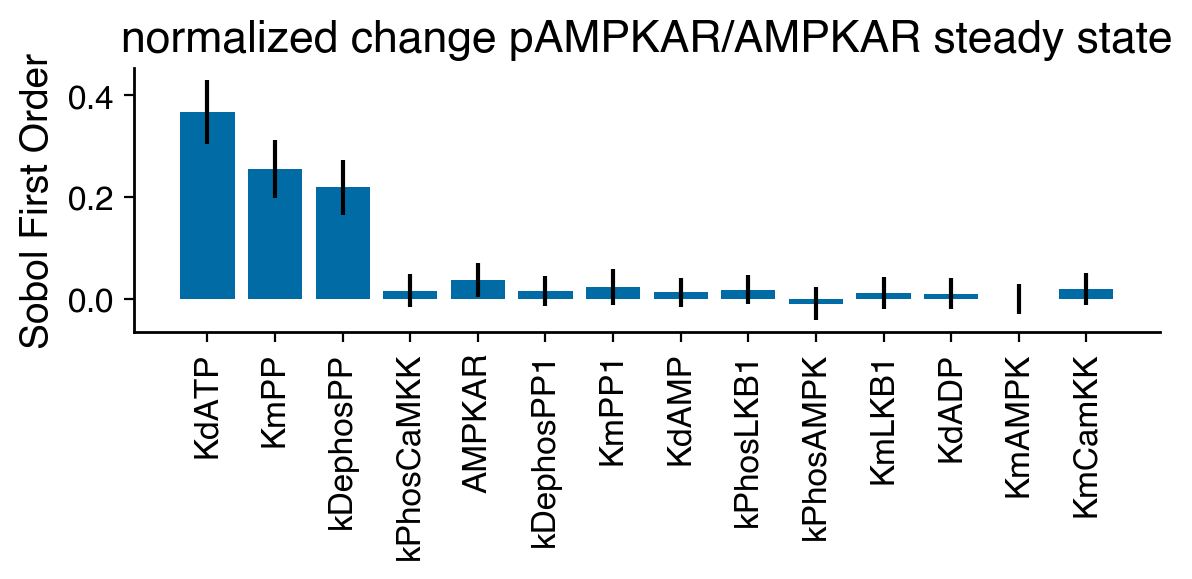

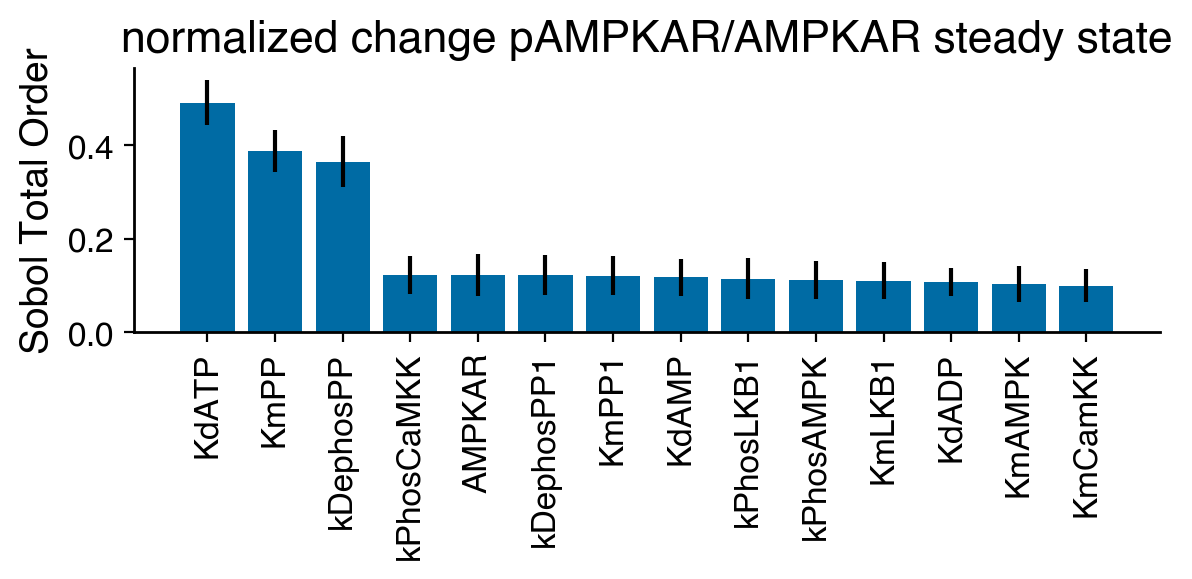

In [80]:
fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,14), Si_sobol_delta_sorted['S1'],
        yerr=Si_sobol_delta_sorted['S1_conf'],
        log=False)
plt.xticks(np.arange(0,14), Si_sobol_delta_sorted['name'], rotation='vertical')
plt.ylabel('Sobol First Order')
plt.title('normalized change pAMPKAR/AMPKAR steady state', weight='normal')
fig.savefig('./MM_single_mech/S1_change.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,14), Si_sobol_delta_sorted['ST'],
        yerr=Si_sobol_delta_sorted['ST_conf'],
        log=False)
plt.xticks(np.arange(0,14), Si_sobol_delta_sorted['name'], rotation='vertical')
plt.ylabel('Sobol Total Order')
plt.title('normalized change pAMPKAR/AMPKAR steady state', weight='normal')
fig.savefig('./MM_single_mech/ST_change.pdf')
plt.show()

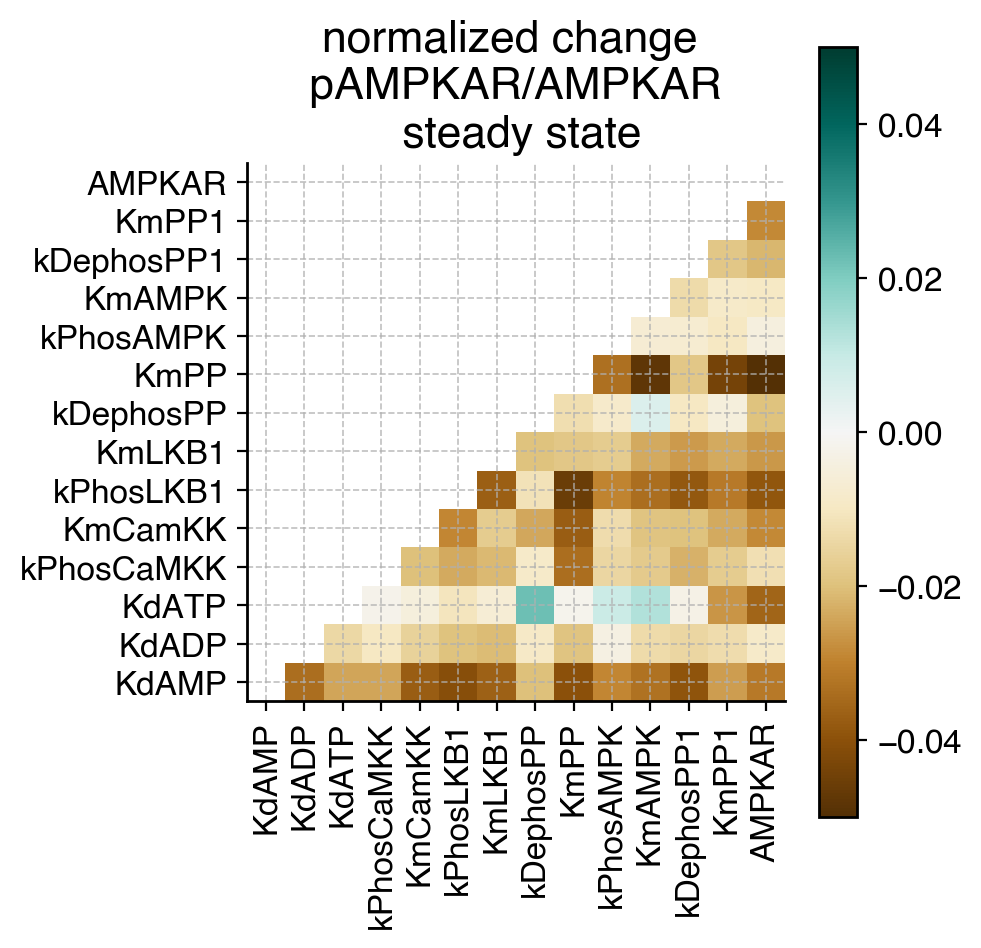

In [81]:
# plot second order
fig, ax = plt.subplots(figsize=(5,5))
cf = ax.pcolormesh(Si_sobol_delta['S2'], vmin=-0.05, vmax=0.05, cmap='BrBG')
fig.colorbar(cf, ax=ax)
ax.set_xticks(np.arange(0,len(param_names_MM))+0.5, labels=param_names_MM, rotation='vertical')
ax.set_yticks(np.arange(0,len(param_names_MM))+0.5, labels=param_names_MM)
ax.grid(True)
ax.set_aspect('equal')
ax.set_title('normalized change \n pAMPKAR/AMPKAR \n steady state', weight='normal')
fig.savefig('./MM_single_mech/S2_change.pdf')

#### Now for HDMR indices

In [82]:
dtype = [('name', 'U10'), ('Sa', float), ('Sa_conf', float), ('Sb', float), ('Sb_conf', float), ('S', float), ('S_conf', float), ('ST', float), ('ST_conf', float)]

Si_hdmr_delta_sorted = np.array([(name, Sa, Sa_conf, Sb, Sb_conf, S, S_conf, ST, ST_conf) for 
                               name, Sa, Sa_conf, Sb, Sb_conf, S, S_conf, ST, ST_conf in zip(param_names_MM, 
                                                                                             Si_hdmr_delta['Sa'], Si_hdmr_delta['Sa_conf'], 
                                                                                             Si_hdmr_delta['Sb'], Si_hdmr_delta['Sb_conf'],
                                                                                             Si_hdmr_delta['S'], Si_hdmr_delta['S_conf'],
                                                                                             Si_hdmr_delta['ST'], Si_hdmr_delta['ST_conf'])], dtype=dtype)
Si_hdmr_delta_sorted = np.sort(Si_hdmr_delta_sorted, order='S')[::-1]

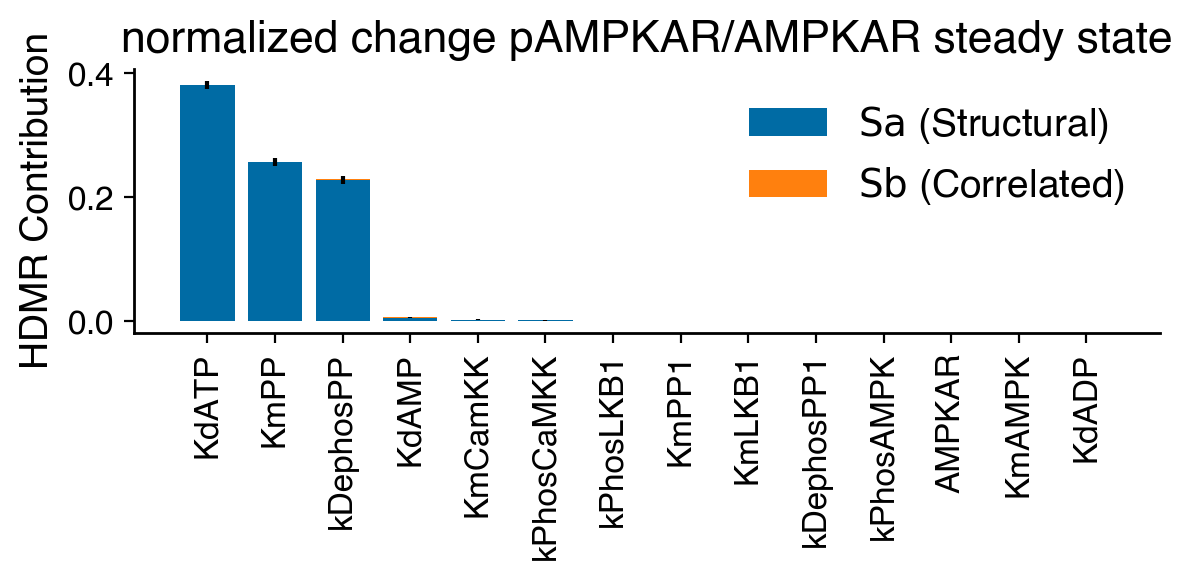

In [83]:
# now visualize the HDMR indices
fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,len(Si_hdmr_delta_sorted['Sa'][0:14])), 
       Si_hdmr_delta_sorted['Sa'][0:14],
       bottom=np.zeros(len(Si_hdmr_delta_sorted['Sa'][0:14])), 
       label=r'$Sa$ (Structural)')
ax.bar(np.arange(0,len(Si_hdmr_delta_sorted['Sb'][0:14])), 
       Si_hdmr_delta_sorted['Sb'][0:14],
       bottom=Si_hdmr_delta_sorted['Sa'][0:14], 
       label=r'$Sb$ (Correlated)',
       yerr=Si_hdmr_delta_sorted['S_conf'])
plt.xticks(np.arange(0, len(Si_hdmr_delta_sorted['name'][0:14])), Si_hdmr_delta_sorted['name'][0:14], rotation='vertical')
plt.ylabel('HDMR Contribution')
plt.legend()
plt.title('normalized change pAMPKAR/AMPKAR steady state', weight='normal')
plt.show()
fig.savefig('./MM_single_mech/hdmr_change.pdf')

Plot trajectories of simulations to test params

In [84]:
# initial conditions
state_names = ['AMP', 'ADP', 'ATP', 'AMPK', 'pAMPK', 'AMP_AMPK', 'ADP_AMPK', 'ATP_AMPK', 'AMP_pAMPK', 'ADP_pAMPK', 'ATP_pAMPK', 'AMPKAR', 'pAMPKAR']

# initial conditions
to_set = ['AMP', 'ADP', 'ATP', 'AMPK', 'AMPKAR']
idxs = [state_names.index(item) for item in to_set]

print(idxs)

y0 = np.zeros((13,))
y0[idxs[0]] = 2e-5   # 'AMP' mM
y0[idxs[1]] = 1.3e-1 # 'ADP mM
y0[idxs[2]] = 8.2   # 'ATP mM
y0[idxs[3]] = 0.6   # 'AMPK mM
y0[idxs[4]] = 1.0   # 'AMPKAR mM

y0 = np.array(y0)

# function to compute all MA params from sampled params
def compute_MM_params(params):
    return (
        1.0, # kOnAMP
        params[0], # kOffAMP
        1.0 , # kOnADP
        params[1], # kOffADP
        1.0, # kOnATP
        params[2], # kOffATP
        params[3], # kCaMKK
        params[4],  # KmCaMKK
        params[5], # kLKB1
        params[6],  # KmLKB1
        params[7], # kPP
        params[8], # KmPP
        params[9], # kAMPK
        params[10], # KmAMPK
        params[11], # kPP1
        params[12], # KmPP1
        1.0, # CaMKKtot
        1.0, # LKB1tot
        1.0, # PPtot
        1.0, # PP1tot
    )

# parameters
# metabolism_params
metab_parms_basal = {'kGly': 1300.0,'kHydro':1.4e-3,'kForAK':40.44,
                     'kRevAK':1.1e-3,'VmaxOxPhos':0.5,'Kadp': 5.8e-2,'n': 2.568,}
metab_parms_stress = {'kGly': 4.5,'kHydro':1.4e-3,'kForAK':40.44,
                      'kRevAK':1.1e-3,'VmaxOxPhos':0.5,'Kadp': 5.8e-2,'n': 2.568,}

## Now test a solve to steady-state function
@jax.jit
def solve_model(params, rhs, y0, t1, times):
    y0 = y0.at[11].set(params[-1])
    params = compute_MM_params(params)
    solver=dfrx.Kvaerno5()
    stepsize_controller = dfrx.PIDController(rtol=1e-10, atol=1e-10)
    t0 = 0.0
    # times = jnp.arange(t0, t1, 0.5)
    dt0 = 1e-8 # initial time step
    saveat=dfrx.SaveAt(ts=times)

    # initial solve
    sol = dfrx.diffeqsolve(
        rhs, 
        solver, 
        t0, t1, dt0, 
        y0, 
        saveat=saveat, stepsize_controller=stepsize_controller,
        args=params)
    
    return sol # returns the final state

################################################
#                   Model RHS                  #
################################################
rhs = model.ampk_MM_single_mech(**metab_parms_basal)
rhs_stress = model.ampk_MM_single_mech(**metab_parms_stress)
rhs = dfrx.ODETerm(rhs)
rhs_stress = dfrx.ODETerm(rhs_stress)

# run once to compile
# sol = single_model_eval(nominal_vals_MM, rhs, rhs_stress, y0, ampkar_idx=11, pampkar_idx=12)
times = jnp.arange(0.0, 1000.0, 0.5)
sol = solve_model(compute_MM_params(nominal_vals_MM), rhs_stress, y0, 1000.0, times)

[0, 1, 2, 3, 11]


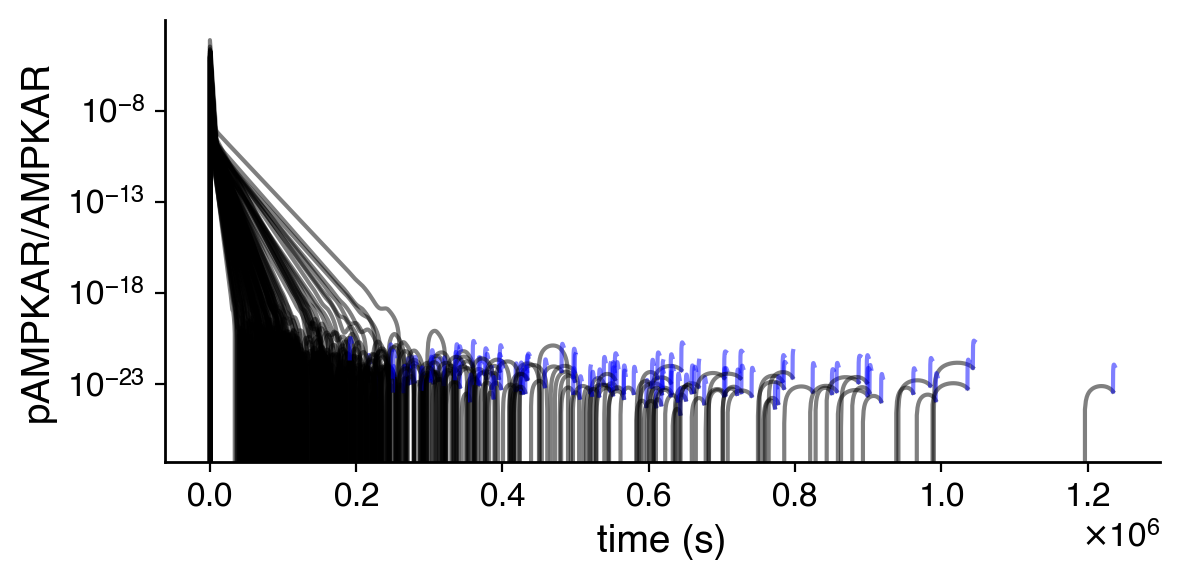

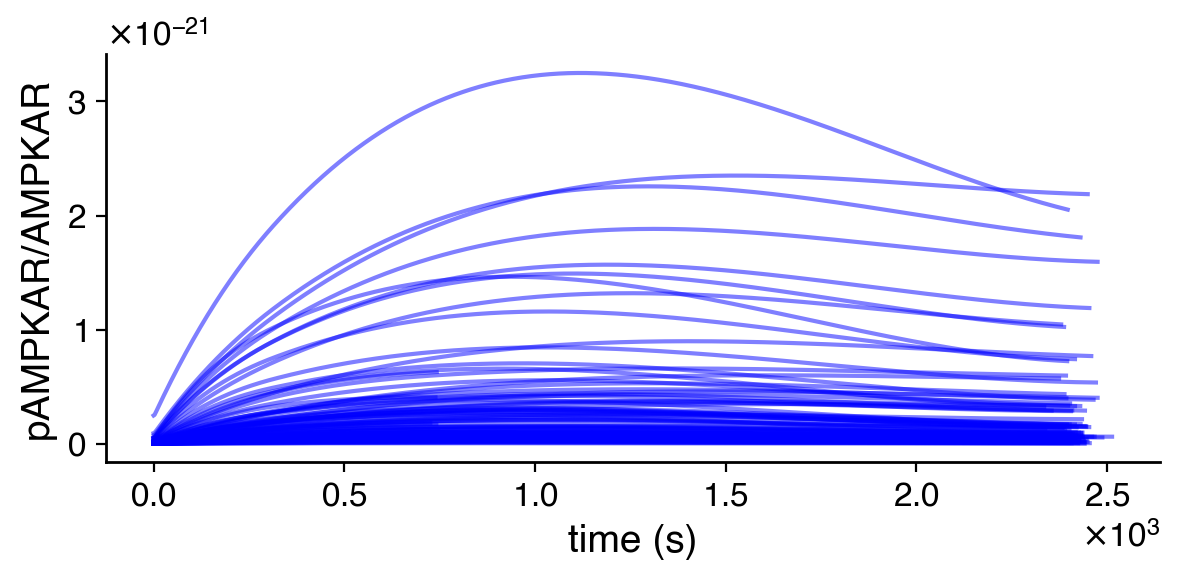

In [85]:
# draw some random samples from the parameter vector
n_samples = 100
idxs = np.random.choice(np.arange(len(param_vals_sobol_corr)), size=(n_samples,), replace=False)

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
fig1, ax1 = plt.subplots(1, 1, figsize=(6, 3))
for i in range(n_samples):
    # get the sample
    sample = param_vals_sobol_corr[idxs[i],:]
    sol = sobol_sols_corr[idxs[i],:]
    # run the model to initial steady-state
    times = jnp.arange(0.0, sol[1], sol[1]/1000)
    sol_1 = solve_model(sample, rhs, y0, sol[1], times)
    # now actually run to get a solution
    # note sol[0] will be the ic and sol[1] will be the time to steady-state
    times = jnp.arange(0.0, sol[2], sol[2]/1000)
    sol_2 = solve_model(sample, rhs_stress, sol_1.ys[-1,:], sol[2], times)
    # plot the solution
    ax.plot(sol_1.ts, sol_1.ys[:,12]/sol_1.ys[:,11], 'k', label=f'sample {idxs[i]}', alpha=0.5)
    ax.plot(sol_1.ts[-1]+sol_2.ts, sol_2.ys[:,12]/sol_2.ys[:,11], 'b', label=f'sample {idxs[i]}', alpha=0.5)
    ax1.plot(sol_2.ts, sol_2.ys[:,12]/sol_2.ys[:,11], 'b', label=f'sample {idxs[i]}', alpha=0.5)

ax.set_yscale('log')
ax.set_xlabel('time (s)')
ax.set_ylabel('pAMPKAR/AMPKAR')
fig.savefig('./MM_single_mech/stress_responses.pdf', bbox_inches='tight')

# ax1.set_yscale('log')
ax1.set_xlabel('time (s)')
ax1.set_ylabel('pAMPKAR/AMPKAR')
fig1.savefig('./MM_single_mech/stress_only_responses.pdf', bbox_inches='tight')